In [89]:
from IndividualParcellation.global_config import *
import pickle
import numpy as np
import pandas as pd
import torch as pt
import nitools as nt
import seaborn as sns
import SUITPy.flatmap as flatmap
import matplotlib.pyplot as plt
import nilearn.plotting as plotting
from Functional_Fusion.dataset import DataSetMDTB
from Functional_Fusion.dataset import DataSetLanguage
import Functional_Fusion.atlas_map as am
import HierarchBayesParcel.full_model as fm
import HierarchBayesParcel.util as ut
import HierarchBayesParcel.emissions as em
import HierarchBayesParcel.evaluation as ev
from FusionModel.evaluate import calc_test_dcbc, compute_dist,calc_test_error
from MultiTaskBattery.optimal_battery import align_conditions, find_optimal_battery

# Constants

For this analysis , I will use a mask that includes D + S regions

In [90]:
# Define ROIs to be used for the analysis
base_dir = '/cifs/diedrichsen/data/FunctionalFusion'
ROI_cerebellum=['S1L', 'S1R', 'S2L', 'S2R', 'S3L', 'S3R', 'S4L', 'S4R','D1L', 'D1R', 'D2L', 'D2R', 'D3L', 'D3R', 'D4L', 'D4R']
ROI_cortex = [6,7] # only used if space is fs32k
space = 'SUIT3'
atlas, _ = am.get_atlas(space)

In [91]:
# Check if CUDA is available
device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


# Step 1: Load group parcellations for ROI specific analysis

In [92]:
if space == 'fs32k':
    atlas_dir = f'{base_dir}/Atlases/tpl-fs32k'
    model_name_L = f'{atlas_dir}/yeo7.L.label.gii'
    model_name_R = f'{atlas_dir}/yeo7.R.label.gii'

    yeo_parcels = atlas.read_data([model_name_L,model_name_R])
    ROI_mask = np.isin(yeo_parcels, ROI_cortex).astype(int)

elif space == 'SUIT3':
    atlas_dir = f'{base_dir}/Atlases/tpl-SUIT'
    model_name = f'/atl-NettekovenSym32_space-SUIT_dseg.nii'
    U = atlas.read_data(atlas_dir + model_name)
    U = U.T
    _, cmap, labels = nt.read_lut(f'{atlas_dir}/atl-NettekovenSym32.lut')
    ROI_mask = np.zeros_like(U)
    for i, label in enumerate(labels):
        if label in ROI_cerebellum:
            ROI_mask[U == i] = 1

else:
    print('atlas space not supported')

# Sanity check: Plot ROI

In [93]:
# if space == 'fs32k':
#     surfs = [base_dir+ "/Atlases" + f'/tpl-fs32k/tpl-fs32k_hemi-{h}_inflated.surf.gii' for i, h in enumerate(['L', 'R'])]
#     mask_reshaped = ROI_mask[np.newaxis, :]  # Reshape to (1, 59518)

#     # Convert to CIFTI format
#     cifti = atlas.data_to_cifti(mask_reshaped)

#     # Extract the data for the cortical surfaces
#     all_img = nt.surf_from_cifti(cifti)

#     # Plot cortical maps for left and right hemispheres
#     fig, axes = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=(12, 6))
#     for h, hemi in enumerate(['left', 'right']):
#         plotting.plot_surf_stat_map(
#             surfs[h], all_img[h], hemi=hemi,
#             colorbar=False,
#             cmap='binary',
#             axes=axes[h],
#             threshold = 0.1,
#             title=f"{ROI_cortex} - {hemi.capitalize()} Hemisphere")

# elif space =='SUIT3':
#     lang_img = atlas.data_to_nifti(ROI_mask)
#     surface = flatmap.vol_to_surf(lang_img, space='SUIT',stats = 'mode')
#     flatmap.plot(data=surface, new_figure=True, colorbar=True, render='matplotlib')

# else:
#     print('not supported')

# Step 2a: Load datasets for search algorithm

Here I'm using MDTB-s1 for search algorithm

In [128]:
Language_class = DataSetLanguage(f'{base_dir}/Language')
subj_list = ['sub-02','sub-03','sub-07','sub-09','sub-10','sub-13']
data_lang_s1,info_lang_s1  =Language_class.get_data(space=space,ses_id='ses-localizer_cond',type='CondRun',subj=subj_list)

# make nans zero
data_lang_s1[np.isnan(data_lang_s1)] = 0

# subtract the mean across conditions from each subject
mean_across_conditions = data_lang_s1.mean(axis=1)
data_lang_s1 = data_lang_s1 - mean_across_conditions[:,np.newaxis,:]

# strip info column taskName from spaces
info_lang_s1['taskName'] = info_lang_s1['taskName'].str.strip()




# Step 2b: Apply mask to data

In [129]:
task_matrix = data_lang_s1 * ROI_mask
task_names = info_lang_s1.taskName.values


# Step 3: Run search algorithm

Run search algorithm on averaged group data

In [130]:
# Run the algorithm to find top combinations
top_combinations = find_optimal_battery(
    task_matrix, 
    task_names, 
    num_tasks=8, 
    function='trace', 
    top_n=1, 
    sample_size=None,
    average_across_subjects=False
)

# Print the top combinations with their corresponding task names
for i, (value, comb) in enumerate(top_combinations, start=1):
    combo_task_names = [info_lang_s1.taskName.values[index] for index in comb]
    print(f'Combination {i}:', combo_task_names)

Processing sample 1/1081575
Processing sample 100001/1081575
Processing sample 200001/1081575
Processing sample 300001/1081575
Processing sample 400001/1081575
Processing sample 500001/1081575
Processing sample 600001/1081575
Processing sample 700001/1081575
Processing sample 800001/1081575
Processing sample 900001/1081575
Processing sample 1000001/1081575
Combination 1: ['tongue_movement', 'tongue_movement', 'theory_of_mind', 'auditory_narrative', 'demand_grid', 'demand_grid', 'romance_movie', 'romance_movie']


In [131]:
# Run the algorithm to find top combinations
top_combinations = find_optimal_battery(
    task_matrix, 
    task_names, 
    num_tasks=8, 
    function='inverse_trace', 
    top_n=1, 
    sample_size=None,
    average_across_subjects=False
)

# Print the top combinations with their corresponding task names
for i, (value, comb) in enumerate(top_combinations, start=1):
    combo_task_names = [info_lang_s1.taskName.values[index] for index in comb]
    print(f'Combination {i}:', combo_task_names)

Processing sample 1/1081575
Processing sample 100001/1081575
Processing sample 200001/1081575
Processing sample 300001/1081575
Processing sample 400001/1081575
Processing sample 500001/1081575
Processing sample 600001/1081575
Processing sample 700001/1081575
Processing sample 800001/1081575
Processing sample 900001/1081575
Processing sample 1000001/1081575
Combination 1: ['rest', 'rest', 'intact_passage', 'finger_sequence', 'oddball', 'sentence_reading', 'sentence_reading', 'sentence_reading']


In [132]:
# Run the algorithm to find top combinations
top_combinations = find_optimal_battery(
    task_matrix, 
    task_names, 
    num_tasks=8, 
    function='determinant', 
    top_n=1, 
    sample_size=None,
    average_across_subjects=False
)

# Print the top combinations with their corresponding task names
for i, (value, comb) in enumerate(top_combinations, start=1):
    combo_task_names = [info_lang_s1.taskName.values[index] for index in comb]
    print(f'Combination {i}:', combo_task_names)

Processing sample 1/1081575
Processing sample 100001/1081575
Processing sample 200001/1081575
Processing sample 300001/1081575
Processing sample 400001/1081575
Processing sample 500001/1081575
Processing sample 600001/1081575
Processing sample 700001/1081575
Processing sample 800001/1081575
Processing sample 900001/1081575
Processing sample 1000001/1081575
Combination 1: ['action_observation_action', 'tongue_movement', 'finger_sequence', 'theory_of_mind', 'auditory_narrative', 'n_back', 'oddball', 'romance_movie']


# Step 4a: Evaluate using DCBC

loading data again, here mdtb-s1 is used for fitting emission models for the task batteries

mdtb-s2 will be used for the evaluation

In [99]:
train_obj = DataSetLanguage(f'{base_dir}/Language')
data_train,info_train  =train_obj.get_data(space=space,ses_id='ses-localizer_cond',type='CondRun',subj=subj_list)

# #include only half 1 of the data and info, first find indices of half 1 from the column called half
# idx = info_train['half'] == 1

# data_train = data_train[:,idx,:]
# info_train = info_train[idx].reset_index(drop=True)


# subtract the mean across conditions from each subject
mean_across_conditions = data_train.mean(axis=1)
data_train = data_train - mean_across_conditions[:,np.newaxis,:]

# strip info column taskName from spaces
info_train['taskName'] = info_train['taskName'].str.strip()


data_train = data_train * ROI_mask

In [100]:
# test_obj = DataSetLanguage(f'{base_dir}/Language')
# data_test,info_test  =train_obj.get_data(space=space,ses_id='ses-localizer_cond',type='CondRun')

# idx = info_test['half'] == 2

# data_test = data_test[:,idx,:]
# info_test = info_test[idx].reset_index(drop=True)


# # subtract the mean across conditions from each subject
# mean_across_conditions = data_test.mean(axis=1)
# data_test = data_test - mean_across_conditions[:,np.newaxis,:]

# # strip info column taskName from spaces
# info_test['taskName'] = info_test['taskName'].str.strip()


# data_test = data_test * ROI_mask

In [101]:
test_obj = DataSetLanguage(f'{base_dir}/Language')
data_test,info_test  =test_obj.get_data(space=space,ses_id='ses-sencoding_category_duration',type='CondRun',subj=subj_list)

# subtract the mean across conditions from each subject
mean_across_conditions = data_test.mean(axis=1)
data_test = data_test - mean_across_conditions[:,np.newaxis,:]

# strip info column taskName from spaces
info_test['taskName'] = info_test['taskName'].str.strip()


data_test = data_test * ROI_mask

Load group parcellations. These are just fullmodels, that have trained arrangament models. The arrangement models were trained on MDTB-s1 + language localizer (ses-01), initialized with different Ks

In [102]:
# Define the directory and k-values
directory = '/cifs/diedrichsen/data/Cerebellum/Language/ProbabilisticParcellations/'
k_values = [2,8,16,22,32]
models = []

# Load all models dynamically
for k in k_values:
    model_path = f'{directory}/language-localizer_mdtb-s1_fusion_k{k}_{space}.pkl'
    with open(model_path, 'rb') as file:
        model = pickle.load(file)
        models.append(model)

In [133]:
# Define task battery
trace_battery = ['tongue_movement', 'tongue_movement', 'theory_of_mind', 'auditory_narrative', 'demand_grid', 'demand_grid', 'romance_movie', 'romance_movie']
inverse_trace_battery = ['rest', 'rest', 'intact_passage', 'finger_sequence', 'oddball', 'sentence_reading', 'sentence_reading', 'sentence_reading']
determinant_battery = ['action_observation_action', 'tongue_movement', 'finger_sequence', 'theory_of_mind', 'auditory_narrative', 'n_back', 'oddball', 'romance_movie']
conventional_battery = ['intact_passage','degraded_passage']*4

# Create localizer subsets
trace_indices = []
inverse_trace_indices = []
determinant_indices = []
conventional_indices = []

for task in trace_battery:
    task_indices = info_train[info_train['taskName'] == task].index.tolist()
    task_index = np.random.choice(task_indices)
    while task_index in trace_indices:
        task_index = np.random.choice(task_indices)
    trace_indices.append(task_index)

for task in inverse_trace_battery:
    task_indices = info_train[info_train['taskName'] == task].index.tolist()
    task_index = np.random.choice(task_indices)
    while task_index in inverse_trace_indices:
        task_index = np.random.choice(task_indices)
    inverse_trace_indices.append(task_index)

for task in determinant_battery:
    task_indices = info_train[info_train['taskName'] == task].index.tolist()
    task_index = np.random.choice(task_indices)
    while task_index in determinant_indices:
        task_index = np.random.choice(task_indices)
    determinant_indices.append(task_index)

for task in conventional_battery:
    task_indices = info_train[info_train['taskName'] == task].index.tolist()
    task_index = np.random.choice(task_indices)
    while task_index in conventional_indices:
        task_index = np.random.choice(task_indices)
    conventional_indices.append(task_index)


trace_dataset = data_train[:,trace_indices, :]
inverse_trace_dataset = data_train[:,inverse_trace_indices, :]
determinant_dataset = data_train[:,determinant_indices, :]
conventional_dataset = data_train[:,conventional_indices, :]


In [134]:
cond_v_train = np.arange(1, trace_dataset.shape[1] + 1)
part_v_train = np.ones(trace_dataset.shape[1])

In [135]:
dist = compute_dist(atlas.world.T, resolution=1)
ROI_mask_tensor = pt.tensor(ROI_mask, dtype=pt.bool)
masked_dist = dist[ROI_mask_tensor][:, ROI_mask_tensor]


In [136]:
def perform_dcbc_eval(model, data_train, data_eval, masked_dist, cond_v_train, part_v_train):
    sym_type = 'unsym'
    ar_model = model.arrange
    x_matrix = ut.indicator(cond_v_train)
    
    if sym_type == 'sym':
        K = ar_model.K_full
    else:
        K = ar_model.K

    print(K)
    
    em_model = em.MixVMF(K=K, P=atlas.P, X=x_matrix, part_vec=part_v_train,
                         subject_specific_kappa=False, parcel_specific_kappa=False, 
                         subjects_equal_weight=True)
    
    M_1 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
    M_1.initialize([data_train])

    M_1, ll,_,U_individual = M_1.fit_em(iter=200, tol=0.01,
                                     fit_arrangement=False,
                                     fit_emission= True,
                                     first_evidence=False)
    
    print(M_1.emissions[0].kappa)


    # Get the data-only parcellation
    emloglik = M_1.emissions[0].Estep()
    U_data = pt.softmax(emloglik, dim=1) # get data only parcellation

    parcellation = U_data
    
    if isinstance(data_eval, np.ndarray):
        data_eval = pt.tensor(data_eval, dtype=pt.get_default_dtype())
    if isinstance(parcellation, np.ndarray):
        parcellation = pt.tensor(parcellation, dtype=pt.get_default_dtype())
    
    Pindiv = pt.argmax(parcellation, dim=1) + 1
    dcbc_indiv = calc_test_dcbc(Pindiv, data_eval, masked_dist)
    return dcbc_indiv

In [137]:
# Compute DCBC for all models
trace_dcbc = []
inverse_trace_dcbc = []
determinant_dcbc = []
conventional_dcbc = []

for model in models:
    trace_dcbc.append(perform_dcbc_eval(model, trace_dataset, data_test, masked_dist, cond_v_train, part_v_train))
    inverse_trace_dcbc.append(perform_dcbc_eval(model, inverse_trace_dataset, data_test, masked_dist, cond_v_train, part_v_train))
    determinant_dcbc.append(perform_dcbc_eval(model, determinant_dataset, data_test, masked_dist, cond_v_train, part_v_train))
    conventional_dcbc.append(perform_dcbc_eval(model, conventional_dataset, data_test, masked_dist, cond_v_train, part_v_train))


2
tensor(0.8676)
Subject 0:6.3858s
Subject 1:11.3119s
Subject 2:9.2355s
Subject 3:5.5342s
Subject 4:11.6292s
Subject 5:10.0251s
Subject 6:11.8364s
Subject 7:11.3622s
Subject 8:11.2327s
Subject 9:11.1792s
Subject 10:11.8888s
Subject 11:13.4387s
Subject 12:11.6996s
Subject 13:10.2969s
Subject 14:11.1676s
Subject 15:11.8270s
Subject 16:11.4543s
2
tensor(0.8578)
Subject 0:11.3878s
Subject 1:11.7240s
Subject 2:10.6150s
Subject 3:8.7664s
Subject 4:11.1654s
Subject 5:11.9022s
Subject 6:9.5107s
Subject 7:

KeyboardInterrupt: 

<Axes: xlabel='k', ylabel='DCBC'>

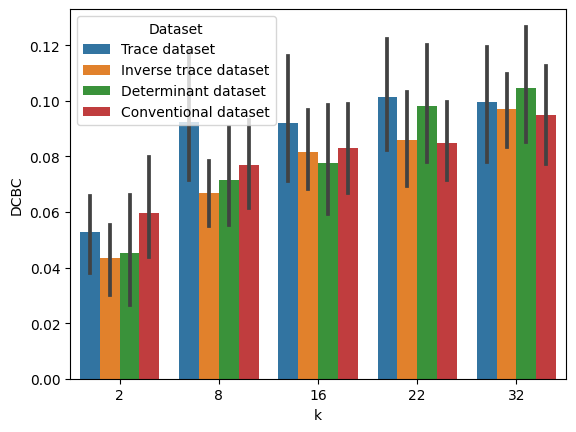

In [127]:
data = []

for k_index, k_value in enumerate(k_values):
    trace_subject_values = trace_dcbc[k_index]
    trace_subject_values = trace_subject_values.cpu().numpy()
    for subject_value in trace_subject_values:
        data.append({'k': k_value, 'DCBC': subject_value, 'Dataset': 'Trace dataset'})

for k_index, k_value in enumerate(k_values):
    inverse_trace_subject_values = inverse_trace_dcbc[k_index]
    inverse_trace_subject_values = inverse_trace_subject_values.cpu().numpy()
    for subject_value in inverse_trace_subject_values:
        data.append({'k': k_value, 'DCBC': subject_value, 'Dataset': 'Inverse trace dataset'})

for k_index, k_value in enumerate(k_values):
    determinant_subject_values = determinant_dcbc[k_index]
    determinant_subject_values = determinant_subject_values.cpu().numpy()
    for subject_value in determinant_subject_values:
        data.append({'k': k_value, 'DCBC': subject_value, 'Dataset': 'Determinant dataset'})

for k_index, k_value in enumerate(k_values):
    conventional_subject_values = conventional_dcbc[k_index]
    conventional_subject_values = conventional_subject_values.cpu().numpy()
    for subject_value in conventional_subject_values:
        data.append({'k': k_value, 'DCBC': subject_value, 'Dataset': 'Conventional dataset'})



df = pd.DataFrame(data)
# Treat the k-values as categorical to avoid interpolation
df['k'] = df['k'].astype('category')

sns.barplot(x='k', y='DCBC', hue='Dataset', data=df)



# Step 5: Evaluate using Cosine error

In [29]:
def perform_coserror_eval(model, data_train, data_eval, cond_v_train, part_v_train):
    sym_type = 'unsym'
    ar_model = model.arrange
    x_matrix = ut.indicator(cond_v_train)
    
    if sym_type == 'sym':
        K = ar_model.K_full
    else:
        K = ar_model.K

    print(K)
    
    em_model = em.MixVMF(K=K, P=atlas.P, X=x_matrix, part_vec=part_v_train,
                         subject_specific_kappa=False, parcel_specific_kappa=False, 
                         subjects_equal_weight=True)
    
    M_1 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
    M_1.initialize([data_train])

    M_1, ll,_,U_individual = M_1.fit_em(iter=200, tol=0.01,
                                     fit_arrangement=False,
                                     fit_emission= True,
                                     first_evidence=False)
    
    print(M_1.emissions[0].kappa)


    # Get the data-only parcellation
    emloglik = M_1.emissions[0].Estep()
    U_data = pt.softmax(emloglik, dim=1) # get data only parcellation

    parcellation = [U_data]
    
    if isinstance(data_eval, np.ndarray):
        data_eval = pt.tensor(data_eval, dtype=pt.get_default_dtype())
    if isinstance(parcellation, np.ndarray):
        parcellation = pt.tensor(parcellation, dtype=pt.get_default_dtype())

    eval_num_runs = 16
    eval_num_conds = 32

    #create cond_vec and part_vec for evaluation data
    cond_v_eval = np.tile(np.arange(1, eval_num_conds + 1), eval_num_runs)
    part_v_eval = np.repeat(np.arange(1, eval_num_runs + 1), eval_num_conds)
    #make into pt tensors
    part_v_eval = pt.tensor(part_v_eval, dtype=pt.long)

    x_matrix  = ut.indicator(cond_v_eval)

    if sym_type == 'sym':
        K = ar_model.K_full
    else:
        K = ar_model.K

    em_model = em.MixVMF(K=K, P=atlas.P, X=x_matrix, part_vec=part_v_eval,
                            subject_specific_kappa=False, parcel_specific_kappa=False, 
                            subjects_equal_weight=True)
    
    M_eval = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
    M_eval.initialize([data_eval])
    
    cosserror_indiv = calc_test_error(M_eval, data_eval, parcellation)
    return cosserror_indiv

In [31]:
# Compute cosserror for all models
trace_coserror = []
inverse_trace_coserror = []
determinant_coserror = []

for model in models:
    trace_coserror.append(perform_coserror_eval(model, trace_dataset, data_mdtb_s2, cond_v_train, part_v_train))
    inverse_trace_coserror.append(perform_coserror_eval(model, inverse_trace_dataset, data_mdtb_s2, cond_v_train, part_v_train))
    determinant_coserror.append(perform_coserror_eval(model, determinant_dataset, data_mdtb_s2, cond_v_train, part_v_train))
    


2
tensor(0.7561)
Subject:0:0.6511s
Subject:1:0.6552s
Subject:2:0.6479s
Subject:3:0.6714s
Subject:4:0.6440s
Subject:5:0.6695s
Subject:6:0.7742s
Subject:7:0.6529s
Subject:8:0.7252s
Subject:9:0.7069s
Subject:10:0.7938s
Subject:11:0.6474s
Subject:12:0.6545s
Subject:13:0.6752s
Subject:14:0.6554s
Subject:15:0.6722s
Subject:16:0.6472s
Subject:17:0.7666s
Subject:18:0.6459s
Subject:19:0.6557s
Subject:20:0.6780s
Subject:21:0.6515s
Subject:22:0.6445s
Subject:23:0.7114s
2
tensor(0.4251)
Subject:0:0.6676s
Subject:1:0.6408s
Subject:2:0.6917s
Subject:3:0.6638s
Subject:4:0.6843s
Subject:5:0.6605s
Subject:6:0.6584s
Subject:7:0.6511s
Subject:8:0.6452s
Subject:9:0.6572s
Subject:10:0.6490s
Subject:11:0.6459s
Subject:12:0.7107s
Subject:13:0.6570s
Subject:14:0.6642s
Subject:15:0.6609s
Subject:16:0.6449s
Subject:17:0.6508s
Subject:18:0.6373s
Subject:19:0.6697s
Subject:20:0.6568s
Subject:21:0.6531s
Subject:22:0.6481s
Subject:23:0.6554s
2
tensor(0.8939)
Subject:0:0.6580s
Subject:1:0.6493s
Subject:2:0.6767s
Sub

/home/ROBARTS/barafat/Documents/GitHub/HierarchBayesParcel/HierarchBayesParcel/full_model.py:305: UserWarning: Likelihood decreased - terminating on iteration 74
  warnings.warn(f'Likelihood decreased - terminating on iteration {i}')


1.4864s
Subject:1:1.2992s
Subject:2:

/home/ROBARTS/barafat/Documents/GitHub/HierarchBayesParcel/HierarchBayesParcel/full_model.py:305: UserWarning: Likelihood decreased - terminating on iteration 68
  warnings.warn(f'Likelihood decreased - terminating on iteration {i}')


1.6244s
Subject:3:

...

2.8361s
Subject:15:3.4460s
Subject:16:

/home/ROBARTS/barafat/Documents/GitHub/HierarchBayesParcel/HierarchBayesParcel/full_model.py:305: UserWarning: Likelihood decreased - terminating on iteration 80
  warnings.warn(f'Likelihood decreased - terminating on iteration {i}')


3.5289s
Subject:17:4.1418s
Subject:18:3.4538s
Subject:19:3.2469s
Subject:20:2.8380s
Subject:21:4.0081s
Subject:22:2.7292s
Subject:23:

/home/ROBARTS/barafat/Documents/GitHub/HierarchBayesParcel/HierarchBayesParcel/full_model.py:305: UserWarning: Likelihood decreased - terminating on iteration 54
  warnings.warn(f'Likelihood decreased - terminating on iteration {i}')


2.9104s
32
tensor(0.5728)
Subject:0:3.2767s
Subject:1:2.8949s
Subject:2:3.1482s
Subject:3:4.5804s
Subject:4:3.3638s
Subject:5:4.2149s
Subject:6:3.4041s
Subject:7:3.8583s
Subject:8:3.5660s
Subject:9:4.3484s
Subject:10:3.4940s
Subject:11:3.3774s
Subject:12:3.3168s
Subject:13:3.9152s
Subject:14:2.6536s
Subject:15:3.0832s
Subject:16:4.1980s
Subject:17:3.7230s
Subject:18:4.2239s
Subject:19:3.5138s
Subject:20:3.7021s
Subject:21:5.2213s
Subject:22:2.7949s
Subject:23:3.1235s
32
tensor(1.0847)
Subject:0:3.1571s
Subject:1:2.7166s
Subject:2:2.9015s
Subject:3:4.3182s
Subject:4:3.2441s
Subject:5:3.7884s
Subject:6:3.7083s
Subject:7:3.2403s
Subject:8:3.9299s
Subject:9:4.1302s
Subject:10:3.1915s
Subject:11:3.3724s
Subject:12:2.5876s
Subject:13:3.4158s
Subject:14:2.6311s
Subject:15:3.1253s
Subject:16:3.8956s
Subject:17:3.4941s
Subject:18:3.4669s
Subject:19:3.4439s
Subject:20:2.9844s
Subject:21:3.6713s
Subject:22:2.4430s
Subject:23:2.9758s


<Axes: xlabel='k', ylabel='coserr'>

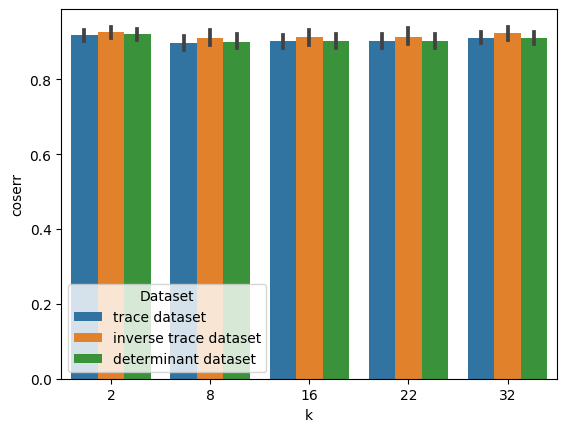

[AFI-CBS-H-11:90068] tcp_peer_recv_connect_ack: invalid header type: 116
[AFI-CBS-H-11:90068] tcp_peer_recv_connect_ack: invalid header type: 96
[AFI-CBS-H-11:90068] tcp_peer_recv_connect_ack: invalid header type: 226
[AFI-CBS-H-11:90068] tcp_peer_recv_connect_ack: invalid header type: 176
[AFI-CBS-H-11:90068] tcp_peer_recv_connect_ack: invalid header type: 202
[AFI-CBS-H-11:90068] tcp_peer_recv_connect_ack: invalid header type: 118
[AFI-CBS-H-11:90068] tcp_peer_recv_connect_ack: invalid header type: 98
[AFI-CBS-H-11:90068] tcp_peer_recv_connect_ack: invalid header type: 128
[AFI-CBS-H-11:90068] tcp_peer_recv_connect_ack: invalid header type: 114
[AFI-CBS-H-11:90068] tcp_peer_recv_connect_ack: invalid header type: 0
[AFI-CBS-H-11:90068] tcp_peer_recv_connect_ack: invalid header type: 0


In [32]:
data = []

for k_index, k_value in enumerate(k_values):
    trace_subject_values = trace_coserror[k_index]
    for subject_value in trace_subject_values:
        data.append({'k': k_value, 'coserr': subject_value, 'Dataset': 'trace dataset'})

for k_index, k_value in enumerate(k_values):
    inverse_trace_subject_values = inverse_trace_coserror[k_index]
    for subject_value in inverse_trace_subject_values:
        data.append({'k': k_value, 'coserr': subject_value, 'Dataset': 'inverse trace dataset'})                                                                                                            

for k_index, k_value in enumerate(k_values):
    determinant_subject_values = determinant_coserror[k_index]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
    for subject_value in determinant_subject_values:                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
        data.append({'k': k_value, 'coserr': subject_value, 'Dataset': 'determinant dataset'})



# Create DataFrame for plotting
df = pd.DataFrame(data)
df = df.explode('coserr')


sns.barplot(x='k', y='coserr', hue='Dataset', data=df)

